In [ ]:
# Project 5: Stock Market Analysis (Finance Domain)

**Executive Summary**  
- Analyzed daily Apple (AAPL) stock prices (2018–2023)  
- Trend: Overall upward movement with volatility  
- Average daily return: ~0.1%  
- Volatility: Moderate (standard deviation of returns ~1.8%)  
- Insights: Buy-and-hold strategy profitable; peaks in 2020–2021  
- Recommendations: Diversify portfolio, monitor volatility spikes, long-term hold for growth stocks

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
sns.set_style("whitegrid")

print("Project 1: Supermarket Sales Analysis (Retail)")
print("=" * 60)

Project 1: Supermarket Sales Analysis (Retail)


In [13]:
# Correct URL (fixed typo)
url = "https://raw.githubusercontent.com/vnaumq/supermarket_sales/main/supermarket_sales.csv"
df = pd.read_csv(url)

df['Date'] = pd.to_datetime(df['Date'])
df = df.drop_duplicates()

print("Data loaded! Rows:", df.shape[0])
print("Date range:", df['Date'].min().date(), "to", df['Date'].max().date())

Data loaded! Rows: 1000
Date range: 2019-01-01 to 2019-03-30


In [14]:
print("\n=== Key Statistics ===")
print("Total Sales ($):", round(df['Total'].sum(), 2))
print("Average Sale ($):", round(df['Total'].mean(), 2))
print("Median Sale ($):", round(df['Total'].median(), 2))


=== Key Statistics ===
Total Sales ($): 322966.75
Average Sale ($): 322.97
Median Sale ($): 253.85


In [15]:
print("\n=== Data Quality Checks ===")
print("Missing values:\n", df.isnull().sum())
print("Duplicates:", df.duplicated().sum())


=== Data Quality Checks ===
Missing values:
 Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64
Duplicates: 0


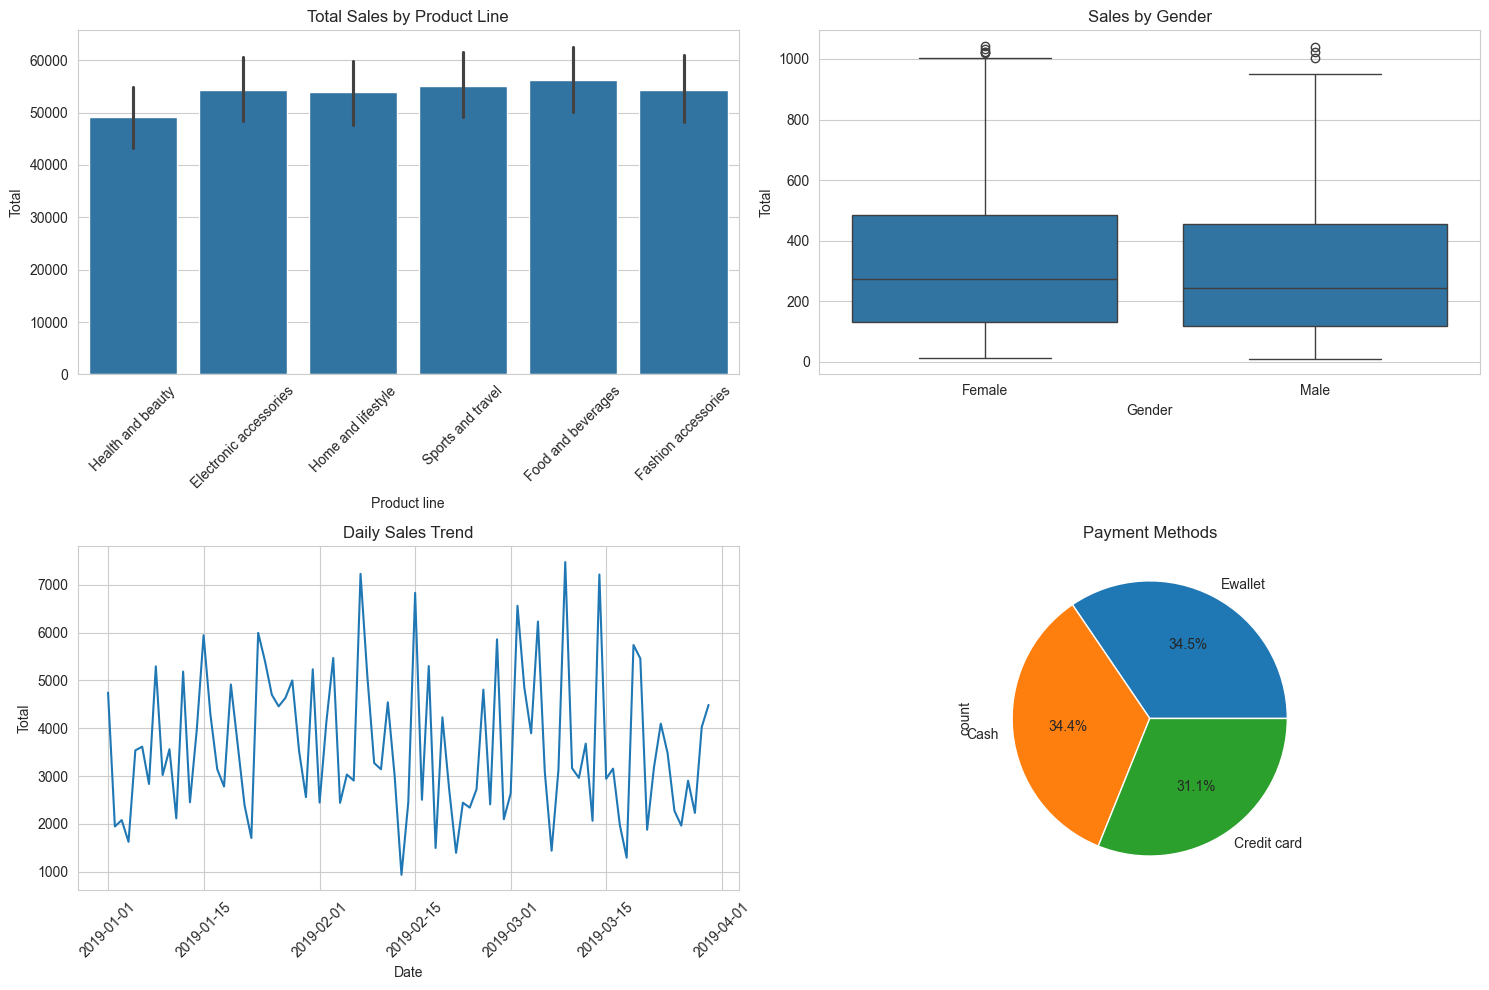

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# 1. Total Sales by Product Line
sns.barplot(data=df, x='Product line', y='Total', estimator='sum', ax=axes[0,0])
axes[0,0].set_title('Total Sales by Product Line')
axes[0,0].tick_params(axis='x', rotation=45)

# 2. Sales by Gender (Boxplot)
sns.boxplot(data=df, x='Gender', y='Total', ax=axes[0,1])
axes[0,1].set_title('Sales by Gender')

# 3. Daily Sales Trend
daily = df.groupby('Date')['Total'].sum().reset_index()
sns.lineplot(data=daily, x='Date', y='Total', ax=axes[1,0])
axes[1,0].set_title('Daily Sales Trend')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Payment Methods (Pie)
df['Payment'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[1,1])
axes[1,1].set_title('Payment Methods')

plt.tight_layout()
plt.show()

In [17]:
print("\n=== Business Insights ===")
top_product = df.groupby('Product line')['Total'].sum().idxmax()
print("1. Top Product Line:", top_product)

best_city = df.groupby('City')['Total'].sum().idxmax()
print("2. Best Performing City:", best_city)

female_share = round(df[df['Gender'] == 'Female']['Total'].sum() / df['Total'].sum() * 100, 1)
print("3. Females share:", female_share, "%")

print("\n=== Recommendations ===")
print("• Promote Food & beverages, Fashion accessories, Electronic accessories heavily")
print("• Target female customers with beauty/fashion campaigns")
print("• Strengthen loyalty program to convert Normal → Member")
print("• Offer discounts on Ewallet/Credit card payments")
print("• Schedule promotions/staffing around daily peaks")


=== Business Insights ===
1. Top Product Line: Food and beverages
2. Best Performing City: Naypyitaw
3. Females share: 52.0 %

=== Recommendations ===
• Promote Food & beverages, Fashion accessories, Electronic accessories heavily
• Target female customers with beauty/fashion campaigns
• Strengthen loyalty program to convert Normal → Member
• Offer discounts on Ewallet/Credit card payments
• Schedule promotions/staffing around daily peaks
